In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import json
import math


from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import  GridSearchCV, KFold
from sklearn.model_selection import RandomizedSearchCV


In [3]:
import xgboost as xgb

In [4]:
data = pd.read_csv('sleeptime_prediction_dataset.csv')
data.head()

,WorkoutTime,ReadingTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime,SleepTime
0,1.12,0.52,3.29,7.89,216.08,0.75,3.45
1,2.85,0.49,4.22,5.03,206.18,0.67,4.88
2,2.20,1.81,4.04,9.23,28.73,0.35,3.61
3,1.80,0.50,1.62,7.68,276.77,1.21,4.94
4,0.47,0.54,1.60,4.94,170.54,0.95,5.50


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WorkoutTime     2000 non-null   float64
 1   ReadingTime     2000 non-null   float64
 2   PhoneTime       2000 non-null   float64
 3   WorkHours       2000 non-null   float64
 4   CaffeineIntake  2000 non-null   float64
 5   RelaxationTime  2000 non-null   float64
 6   SleepTime       2000 non-null   float64
dtypes: float64(7)
memory usage: 109.5 KB


In [6]:
data.describe()

,WorkoutTime,ReadingTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime,SleepTime
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1.495915,0.992785,2.985195,6.926945,147.493780,1.010955,4.884375
std,0.876639,0.577303,1.151776,1.723843,84.651139,0.582619,2.028892
min,0.010000,0.000000,1.000000,4.000000,0.020000,0.000000,0.150000
25%,0.710000,0.500000,1.990000,5.440000,75.980000,0.510000,3.840000
50%,1.520000,0.990000,2.965000,6.910000,146.010000,1.010000,4.600000
75%,2.250000,1.500000,3.960000,8.422500,218.902500,1.530000,5.470000
max,3.000000,2.000000,5.000000,10.000000,299.850000,2.000000,19.810000


In [7]:
# ReadingTime 제거
data = data.drop('ReadingTime', axis=1)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WorkoutTime     2000 non-null   float64
 1   PhoneTime       2000 non-null   float64
 2   WorkHours       2000 non-null   float64
 3   CaffeineIntake  2000 non-null   float64
 4   RelaxationTime  2000 non-null   float64
 5   SleepTime       2000 non-null   float64
dtypes: float64(6)
memory usage: 93.9 KB


In [9]:
data.describe()

,WorkoutTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime,SleepTime
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1.495915,2.985195,6.926945,147.493780,1.010955,4.884375
std,0.876639,1.151776,1.723843,84.651139,0.582619,2.028892
min,0.010000,1.000000,4.000000,0.020000,0.000000,0.150000
25%,0.710000,1.990000,5.440000,75.980000,0.510000,3.840000
50%,1.520000,2.965000,6.910000,146.010000,1.010000,4.600000
75%,2.250000,3.960000,8.422500,218.902500,1.530000,5.470000
max,3.000000,5.000000,10.000000,299.850000,2.000000,19.810000


In [10]:
# 모든 특성의 이상치 한번에 확인
for col in data.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"{col}: 이상치 {len(outliers)}개 (범위: {lower:.2f}~{upper:.2f})")

WorkoutTime: 이상치 0개 (범위: -1.60~4.56)
PhoneTime: 이상치 0개 (범위: -0.97~6.92)
WorkHours: 이상치 0개 (범위: 0.97~12.90)
CaffeineIntake: 이상치 0개 (범위: -138.40~433.29)
RelaxationTime: 이상치 0개 (범위: -1.02~3.06)
SleepTime: 이상치 64개 (범위: 1.40~7.91)


In [11]:
data_clean = data[(data['SleepTime'] >= lower) & (data['SleepTime'] <= upper)]

print(f"원본 데이터: {len(data)}개")
print(f"이상치 제거 후: {len(data_clean)}개")
print(f"제거된 이상치: {len(data) - len(data_clean)}개 (3.2%)")

원본 데이터: 2000개
이상치 제거 후: 1936개
제거된 이상치: 64개 (3.2%)


In [12]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1936 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WorkoutTime     1936 non-null   float64
 1   PhoneTime       1936 non-null   float64
 2   WorkHours       1936 non-null   float64
 3   CaffeineIntake  1936 non-null   float64
 4   RelaxationTime  1936 non-null   float64
 5   SleepTime       1936 non-null   float64
dtypes: float64(6)
memory usage: 105.9 KB


In [13]:
data_clean.describe()

,WorkoutTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime,SleepTime
count,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000
mean,1.491457,2.993802,6.925744,147.536353,1.007712,4.627614
std,0.875963,1.152276,1.723857,84.292106,0.581714,1.070818
min,0.010000,1.000000,4.000000,0.020000,0.000000,1.550000
25%,0.710000,1.990000,5.440000,76.080000,0.500000,3.820000
50%,1.520000,2.990000,6.905000,146.230000,1.000000,4.560000
75%,2.240000,3.970000,8.420000,217.775000,1.520000,5.390000
max,3.000000,5.000000,10.000000,299.850000,2.000000,7.830000


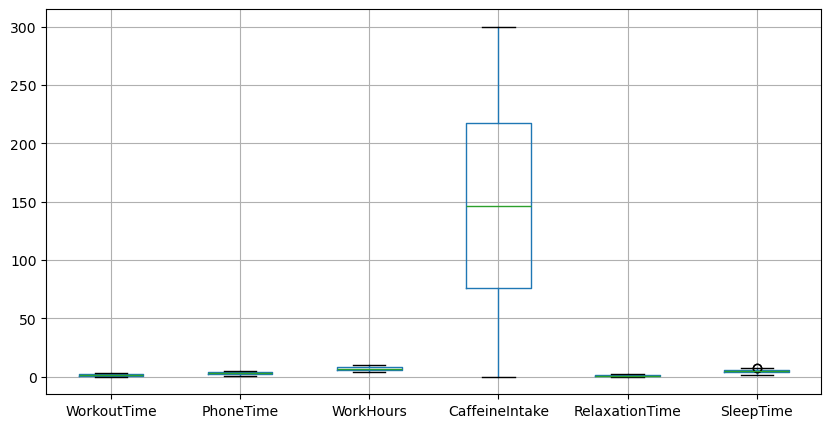

In [14]:
data_clean.boxplot(figsize=(10,5))
plt.show()

In [15]:
X = data_clean.drop('SleepTime', axis=1)
y = data_clean['SleepTime']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1355, 5), (581, 5), (1355,), (581,))

In [18]:
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [19]:
model.score(X_train, y_train)

0.9990901118975148

In [20]:
model.score(X_test, y_test)

0.8785189796402271

In [21]:
# MAE 계산 (평균 절대 오차)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f} 시간")

MAE: 0.24 시간


In [22]:
# RMSE 계산 (평균 제곱근 오차)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f} 시간")

RMSE: 0.37 시간


In [23]:
# R² 계산
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2:.4f}")

R2 Score: 0.8785


In [24]:
cross_val_score(model, X_train, y_train, cv = 10)

array([0.78126833, 0.82379422, 0.76941458, 0.80549252, 0.87892966,
       0.76527066, 0.89293664, 0.90605263, 0.82614692, 0.90527831])

In [54]:
grid_model = xgb.XGBRegressor(random_state=18)

params = {
    # 1. 트리 구성 관련 (모델의 복잡도)
    'n_estimators': [100, 200, 300],          # 트리 개수: 더 많이 학습할 기회를 주어 미세한 오차를 잡음
    'max_depth': [3, 5, 7],                   # 트리 깊이: 너무 깊으면 과적합, 너무 얕으면 과소적합 위험
    'learning_rate': [0.01, 0.05, 0.1],       # 학습률: 가중치 업데이트 강도 (낮을수록 정교하지만 오래 걸림)
    
    # 2. 과적합 방지 및 규제 (3.5시간 근처에만 몰리는 현상 완화)
    'min_child_weight': [1, 3, 5],            # 자식 노드의 최소 가중치 합: 높을수록 모델이 보수적으로 변함
    'gamma': [0, 0.1, 0.2, 0.5],              # 트리 분할을 위한 최소 손실 감소: 클수록 트리를 덜 만듦 (단순화)
    'reg_lambda': [1, 1.5, 2],                # L2 규제: 가중치를 작게 유지하여 특정 피처의 과도한 영향력 억제
    'reg_alpha': [0, 0.1, 0.5],               # L1 규제: 불필요한 피처(노이즈)의 가중치를 0으로 만듦
    
    # 3. 샘플링 (데이터의 다양성 확보)
    'subsample': [0.7, 0.8, 0.9],             # 데이터 샘플링: 매 트리마다 70~90%의 데이터만 사용하여 변동성 부여
    'colsample_bytree': [0.7, 0.8, 0.9],      # 특성 샘플링: 매 트리마다 70~90%의 피처만 선택 (다양한 조합 학습)

    # 4. 학습 목적 함수 (중요!)
    'objective': ['reg:absoluteerror']        # 제곱오차 대신 '절대오차(MAE)' 사용: 극단적인 입력값에 더 민감하게 반응함
}

In [73]:
# 3. 교차검증 방식 (10번 나눠서 검증 유지)
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# 4. RandomizedSearch (n_iter를 1,000으로 대폭 상향)
# 총 1,000(조합) * 10(CV) = 10,000 fits
grid = RandomizedSearchCV(
    grid_model,
    param_distributions=params, 
    n_iter=1000,          # 무작위로 1,000개의 파라미터 조합 시도
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,            # 모든 CPU 코어 동원
    verbose=2,            # 진행 상황 확인
    random_state=42
)

# 5. 학습 (여기서 시간이 좀 걸릴 수 있습니다)
grid.fit(X_train, y_train)

# 6. 결과 확인 (양수 변환)
train_mae = abs(grid.score(X_train, y_train))
cv_mae = abs(grid.best_score_)

print("-" * 30)
print(f"🔥 [초정밀 학습 완료]")
print(f"최종 학습 데이터 오차: {train_mae:.4f} 시간 (약 {train_mae * 60:.1f}분)")
print(f"최고 교차 검증 오차: {cv_mae:.4f} 시간 (약 {cv_mae * 60:.1f}분)")
print("-" * 30)
print("✅ 최적의 파라미터:")
print(grid.best_params_)

Fitting 10 folds for each of 1000 candidates, totalling 10000 fits
------------------------------
🔥 [초정밀 학습 완료]
최종 학습 데이터 오차: 0.1138 시간 (약 6.8분)
최고 교차 검증 오차: 0.2054 시간 (약 12.3분)
------------------------------
✅ 최적의 파라미터:
{'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'objective': 'reg:absoluteerror', 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.9}


In [79]:
# 1. 학습 데이터 점수를 양수로 변환
train_mae_positive = abs(grid.score(X_train, y_train))
print(f"최종 학습 데이터 오차: {train_mae_positive:.4f} 시간")

# 2. 테스트 데이터 점수를 양수로 변환
test_mae_positive = abs(grid.score(X_test, y_test))
print(f"최종 테스트 데이터 오차: {test_mae_positive:.4f} 시간")

# 3. 만약 분 단위로도 보고 싶다면
print(f"테스트 오차(분): {test_mae_positive * 60:.1f} 분")

최종 학습 데이터 오차: 0.1138 시간
최종 테스트 데이터 오차: 0.1916 시간
테스트 오차(분): 11.5 분


In [75]:
grid.best_params_

{'subsample': 0.7,
 'reg_lambda': 1.5,
 'reg_alpha': 0.5,
 'objective': 'reg:absoluteerror',
 'n_estimators': 300,
 'min_child_weight': 5,
 'max_depth': 5,
 'learning_rate': 0.05,
 'gamma': 0,
 'colsample_bytree': 0.9}

In [78]:
grid.score(X_train, y_train)

-0.11375441855961987

In [80]:
grid.score(X_test, y_test)

-0.1915588899733893

In [82]:
# 최적 모델로 예측
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [83]:
print(f"MAE: {mae:.3f} 시간")
print(f"RMSE: {rmse:.3f} 시간")
print(f"R2: {r2:.4f}")

MAE: 0.192 시간
RMSE: 0.306 시간
R2: 0.9166


In [141]:
def get_segmented_sleep_score(hours):
    target = 7.5
    mid_point = 5.0  # 5시간 기준점
    
    # 구간별 sigma 값
    sigma_high = 2.0  # 5~7.5시간 (급격한 감소)
    sigma_low = 1.5  # 2~5시간 (매우 급격한 감소)
    sigma_excess = 5.0 # 7.5시간 초과 (매우 완만)
    
    # 1. 7.5시간 초과
    if hours > target:
        score = 100 * np.exp(-((hours - target)**2) / (2 * sigma_excess**2))
    
    # 2. 5시간 ~ 7.5시간 (급격 감소)
    elif hours >= mid_point:
        score = 100 * np.exp(-((hours - target)**2) / (2 * sigma_high**2))
    
    # 3. 2시간 ~ 5시간 (완만 감소)
    else:
        # 5시간에서의 점수를 기준으로 이어지도록 조정
        score_at_5 = 100 * np.exp(-((mid_point - target)**2) / (2 * sigma_high**2))
        # 5시간 이하 구간은 별도의 sigma로 감소
        score = score_at_5 * np.exp(-((hours - mid_point)**2) / (2 * sigma_low**2))
    
    return round(max(0, score), 1)

# 다양한 수면 시간에 대한 점수 계산
sleep_times = [1, 2, 3, 4, 5, 6, 7, 7.5, 8, 9, 10]
print("="*60)
print("3구간 비대칭 가우시안 점수 (5시간 기준 감소율 분리)")
print("="*60)

for hours in sleep_times:
    score =get_segmented_sleep_score(hours)
    diff = hours - 7.5
    direction = "부족" if diff < 0 else "초과" if diff > 0 else "최적"
    
    print(f"수면 {hours}시간 ({direction:>4}) → {score:>5}점")

3구간 비대칭 가우시안 점수 (5시간 기준 감소율 분리)
수면 1시간 (  부족) →   1.3점
수면 2시간 (  부족) →   6.2점
수면 3시간 (  부족) →  18.8점
수면 4시간 (  부족) →  36.7점
수면 5시간 (  부족) →  45.8점
수면 6시간 (  부족) →  75.5점
수면 7시간 (  부족) →  96.9점
수면 7.5시간 (  최적) → 100.0점
수면 8시간 (  초과) →  99.5점
수면 9시간 (  초과) →  95.6점
수면 10시간 (  초과) →  88.2점


In [85]:
# 한글폰트 적용
plt.rcParams['font.family'] = 'Malgun Gothic'
# 한글폰트 사용 시 마이너스 기호가 네모(ㅁ) 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

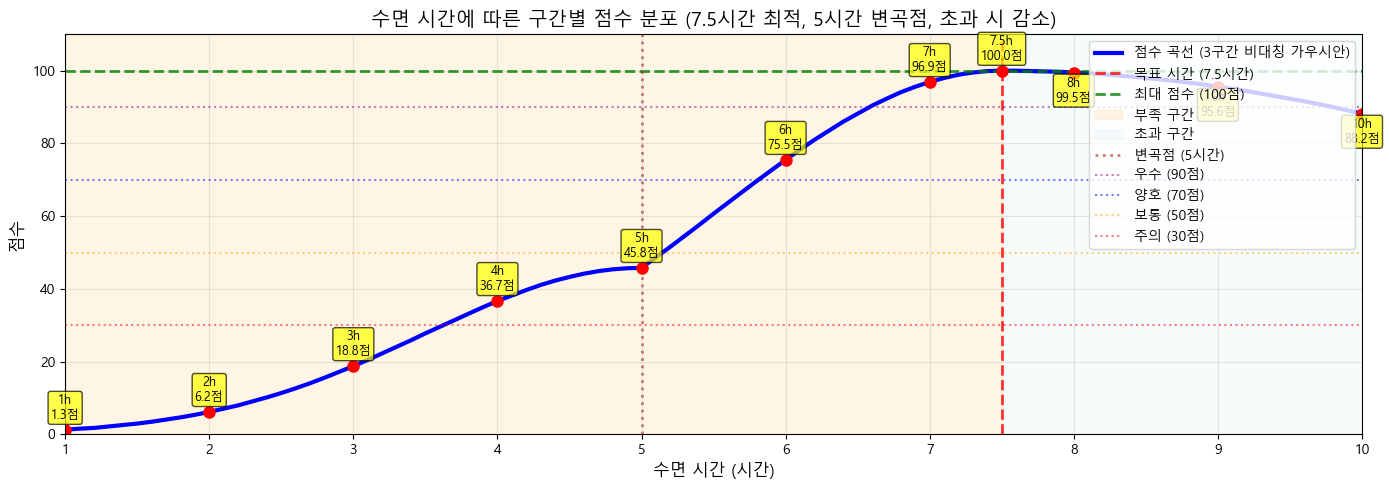

In [140]:
# 그래프
plt.figure(figsize=(14, 5))

# 점수 곡선 (1~10시간)
hours_range = np.arange(1, 10.1, 0.1)
scores = [get_segmented_sleep_score(h) for h in hours_range]
plt.plot(hours_range, scores, 'b-', linewidth=3, label='점수 곡선 (3구간 비대칭 가우시안)')

# 목표 시간
plt.axvline(x=7.5, color='red', linestyle='--', linewidth=2, alpha=0.8, label='목표 시간 (7.5시간)')
plt.axhline(y=100, color='green', linestyle='--', linewidth=2, alpha=0.8, label='최대 점수 (100점)')

# 구역 색칠하기 (부족/초과 구간)
plt.axvspan(1, 7.5, alpha=0.1, color='orange', label='부족 구간')
plt.axvspan(7.5, 10, alpha=0.1, color='lightblue', label='초과 구간')

# 5시간 기준선 추가
plt.axvline(x=5.0, color='brown', linestyle=':', linewidth=2, alpha=0.6, label='변곡점 (5시간)')

# 주요 시간대 점수 표시 (1~10시간)
time_points = [1, 2, 3, 4, 5, 6, 7, 7.5, 8, 9, 10]
for hours in time_points:
    score = get_segmented_sleep_score(hours)
    plt.plot(hours, score, 'ro', markersize=8)
    # 점수 위치에 따라 텍스트 위치 조정
    if hours <= 7.5:
        y_offset = 3
    else:
        y_offset = -8
    
    plt.text(hours, score + y_offset, f'{hours}h\n{score}점', ha='center', fontsize=9, 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

# 등급 구분선
plt.axhline(y=90, color='purple', linestyle=':', alpha=0.5, label='우수 (90점)')
plt.axhline(y=70, color='blue', linestyle=':', alpha=0.5, label='양호 (70점)')
plt.axhline(y=50, color='orange', linestyle=':', alpha=0.5, label='보통 (50점)')
plt.axhline(y=30, color='red', linestyle=':', alpha=0.5, label='주의 (30점)')

plt.grid(True, alpha=0.3)
plt.xlabel('수면 시간 (시간)', fontsize=12)
plt.ylabel('점수', fontsize=12)
plt.title('수면 시간에 따른 구간별 점수 분포 (7.5시간 최적, 5시간 변곡점, 초과 시 감소)', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.ylim(0, 110)
plt.xlim(1, 10)
plt.tight_layout()
plt.show()

In [87]:
import os
import joblib

# =====================================================
# ML 모델 로드
# =====================================================
current_dir = os.getcwd()
print(f"현재 위치: {current_dir}")

# 모델 경로 (여기에 정확한 경로 입력)
model_path = r'c:\Users\SMHRD-\Desktop\SleepRescue2\Node\models\Sleep_XGBoost(ML)\sleep_xgb_model.pkl'

# 모델 로드
try:
    model = joblib.load(model_path)
    print("✅ 모델 로드 성공!")
except FileNotFoundError:
    print(f"❌ 모델 파일을 찾을 수 없습니다: {model_path}")
    print("   경로를 확인해주세요.")

현재 위치: c:\Users\SMHRD-\Desktop\SleepRescue2\Node\models\Sleep_XGBoost(ML)
✅ 모델 로드 성공!


In [88]:
# =====================================================
# 1. 카페인 변환 함수
# =====================================================
def get_caffeine_mg(caffeine_input):
    caffeine_map = {
        '아메리카노': 120, '라떼': 80, '에너지음료': 160, '녹차': 30, '없음': 0
    }
    try:
        return float(str(caffeine_input).replace(',', ''))
    except ValueError:
        return caffeine_map.get(caffeine_input, 0)

In [89]:
# =====================================================
# 2. 모델 로드 (상위 폴더 및 현재 폴더 모두 탐색)
# =====================================================
base_path = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
candidates = [
    os.path.join(base_path, '..', 'models', 'Sleep_XGBoost(ML)', 'sleep_xgb_model.pkl'),
    os.path.join(base_path, 'sleep_xgb_model.pkl')
]

model = None
for path in candidates:
    if os.path.exists(path):
        model = joblib.load(path)
        break

if model is None:
    print(json.dumps({"status": "error", "message": "모델 파일을 찾을 수 없습니다."}))
    sys.exit(1)

def get_asymmetric_sleep_score_v2(hours):
    target, s_before, s_after = 7.5, 3.8, 5.0
    sigma = s_before if hours <= target else s_after
    score = 100 * math.exp(-((hours - target)**2) / (2 * (sigma**2)))
    return round(score, 1)

In [97]:

# =====================================================
# 3. 휴식시간
# =====================================================
if len(sys.argv) == 6:
    # CLI 모드 (운동, 폰, 근무, 카페인, 수면시간)
    try:
        workout = float(sys.argv[1].replace(',', ''))
        phone = float(sys.argv[2].replace(',', ''))
        work_hours = float(sys.argv[3].replace(',', ''))
        caffeine = get_caffeine_mg(sys.argv[4])
        user_sleep = float(sys.argv[5].replace(',', ''))
        mode = "json"
    except Exception as e:
        print(json.dumps({"status": "error", "message": f"입력 오류: {e}"}))
        sys.exit(1)
else:
    # 대화형 모드
    mode = "interactive"
    print("\n" + "="*50)
    print("😴 생활패턴 입력 (직접 입력 모드)")
    print("="*50)
    print("\n[입력 방법]")
    print("  - 카페인: 숫자(mg) 또는 음료명(아메리카노/라떼/에너지음료/녹차/없음) 입력")
    print("-"*50)
    try:
        workout = float(input("\n운동 시간 (시간): "))
        phone = float(input("핸드폰 사용 시간 (시간): "))
        work_hours = float(input("근무 시간 (시간): "))
        caffeine_input = input("카페인 (mg 또는 음료명): ")
        caffeine = get_caffeine_mg(caffeine_input)
        user_sleep = float(input("수면 시간 (시간): "))
    except Exception as e:
        print(f"❌ 입력 오류: {e}")
        sys.exit(1)

# 휴식시간 계산
relaxation = 24 - (workout + phone + work_hours + user_sleep)
relaxation = max(0, relaxation)

print(f"\n 휴식시간: {relaxation:.2f}시간")
print(f"☕ 카페인 섭취량: {caffeine}mg")


😴 생활패턴 입력 (직접 입력 모드)

[입력 방법]
  - 카페인: 숫자(mg) 또는 음료명(아메리카노/라떼/에너지음료/녹차/없음) 입력
--------------------------------------------------

 휴식시간: 7.00시간
☕ 카페인 섭취량: 0.0mg


In [98]:
# =====================================================
# 예측 수면시간 구하기
# =====================================================
input_data = pd.DataFrame([{
    'WorkoutTime': workout,
    'PhoneTime': phone,
    'WorkHours': work_hours,
    'CaffeineIntake': caffeine,
    'RelaxationTime': relaxation
}])

predicted_sleep = round(float(model.predict(input_data)[0]), 1)
sleep_score = get_asymmetric_sleep_score_v2(predicted_sleep)

# =====================================================
# 결과 출력
# =====================================================
if mode == "json":
    result = {
        "status": "success",
        "user_sleep": user_sleep,
        "predicted_sleep": predicted_sleep,
        "relaxation": round(relaxation, 2),
        "caffeine_mg": caffeine,
        "sleep_score": sleep_score
    }
    print(json.dumps(result, ensure_ascii=False))
else:
    print("\n" + "="*50)
    print("📊 분석 결과")
    print("="*50)
    print(f"\n[입력 데이터]")
    print(f"  운동시간: {workout}시간")
    print(f"  폰 사용시간: {phone}시간")
    print(f"  근무시간: {work_hours}시간")
    print(f"  카페인: {caffeine}mg")
    print(f"  휴식시간: {relaxation:.2f}시간 (자동 계산)")
    print(f"\n[사용자 입력 수면시간]")
    print(f"  내 수면시간: {user_sleep}시간")
    print(f"\n[예측 결과]")
    print(f"  AI 예측 수면시간: {predicted_sleep}시간")
    print(f"  수면 점수: {sleep_score}점")
    print("="*50)


📊 분석 결과

[입력 데이터]
  운동시간: 1.0시간
  폰 사용시간: 2.0시간
  근무시간: 8.0시간
  카페인: 0.0mg
  휴식시간: 7.00시간 (자동 계산)

[사용자 입력 수면시간]
  내 수면시간: 6.0시간

[예측 결과]
  AI 예측 수면시간: 4.4시간
  수면 점수: 71.7점


In [99]:
# 모델 저장하기
import joblib

# best_model이 학습된 XGBoost 모델 변수명
# 함수에서 사용하는 변수명이 best_model이니까 이걸로 저장
joblib.dump(best_model, 'sleep_xgb_model.pkl')
print("모델 저장 완료: sleep_xgb_model.pkl")

# 입력 피처 순서 확인 (중요!)
# 모델 학습할 때 사용한 피처 순서와 동일해야 함
print("입력 피처 순서: ['WorkoutTime', 'PhoneTime', 'WorkHours', 'CaffeineIntake', 'RelaxationTime']")
print("순서대로: 운동, 핸드폰, 근무, 카페인, 휴식")

모델 저장 완료: sleep_xgb_model.pkl
입력 피처 순서: ['WorkoutTime', 'PhoneTime', 'WorkHours', 'CaffeineIntake', 'RelaxationTime']
순서대로: 운동, 핸드폰, 근무, 카페인, 휴식


In [100]:
# 특성 중요도 가져오기
feature_importance = best_model.feature_importances_
features = X.columns

In [104]:
# 중요도 순으로 정렬
importance_df = pd.DataFrame({
    'feature': features,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("특성 중요도:")
print(importance_df)


특성 중요도:
          feature  importance
2     WorkoutTime    0.279550
1       WorkHours    0.271347
0       PhoneTime    0.175829
4  CaffeineIntake    0.146200
3  RelaxationTime    0.127075


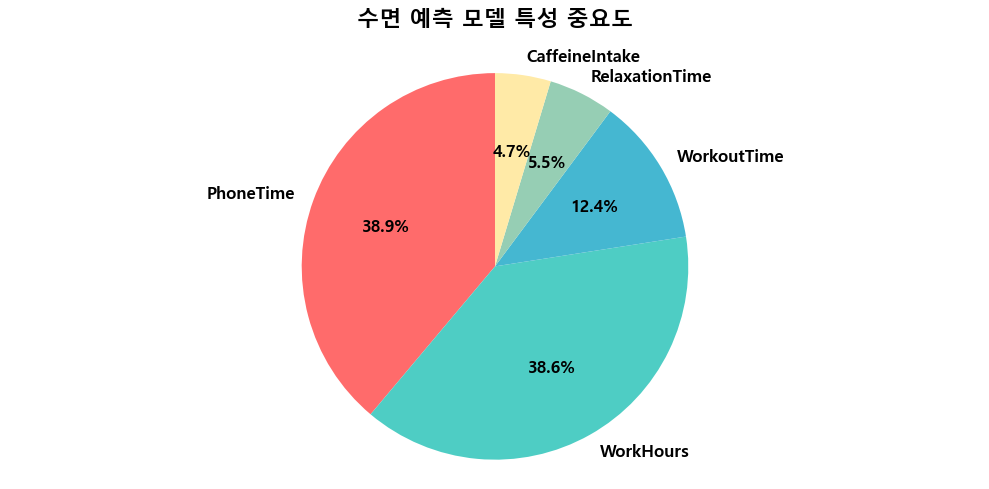

In [105]:
# 시각화
# 특성 중요도 데이터
features = ['PhoneTime', 'WorkHours', 'WorkoutTime', 'RelaxationTime', 'CaffeineIntake']
importances = [0.388706, 0.385960, 0.123566, 0.055226, 0.046542]

# 색상 설정
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffeaa7']

plt.figure(figsize=(10, 5))
plt.pie(importances, 
        labels=features, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=colors,
        textprops={'fontsize': 12, 'weight': 'bold'})

plt.title('수면 예측 모델 특성 중요도', fontsize=16, weight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [106]:
# =====================================================
# 피로 원인 분석 (입력데이터 기준)
# =====================================================

# 위에서 입력받은 값 사용 (workout, phone, work_hours, caffeine, user_sleep)

print(f"📊 입력 데이터:")
print(f"  운동: {workout}시간")
print(f"  휴대폰 사용: {phone}시간")
print(f"  근무: {work_hours}시간")
print(f"  수면: {user_sleep}시간")
print(f"  카페인: {caffeine}mg")
print()

# =====================================================
# 피로 원인 분석 함수 (순위용 - 가중치 적용)
# =====================================================
def analyze_fatigue_cause_with_weight(workout, phone, work_hours, caffeine):
    problem_items = []  # (이름, 값, 설명, 가중치)
    
    # 근무시간에 따른 가중치 조정
    if work_hours <= 2:
        work_factor = 0.2
        work_note = " (근무시간이 매우 짧아 여유로워요)"
    elif work_hours <= 4:
        work_factor = 0.5
        work_note = " (근무시간이 짧아 여유로워요)"
    elif work_hours <= 6:
        work_factor = 0.8
        work_note = " (근무시간이 적당해요)"
    elif work_hours <= 8:
        work_factor = 1.0
        work_note = ""
    else:
        work_factor = 1.2
        work_note = " (과로 상태예요)"
    
    # 1. 휴대폰 사용
    if phone > 5:
        weight = int(4 * work_factor)
        if weight > 0:
            problem_items.append(('📱 휴대폰 사용', phone, f'하루 {phone:.1f}시간 사용하고 있어요 (권장 3시간 이하){work_note}', weight))
    elif phone > 3:
        weight = int(2 * work_factor)
        if weight > 0:
            problem_items.append(('📱 휴대폰 사용', phone, f'하루 {phone:.1f}시간 사용하고 있어요 (권장 3시간 이하){work_note}', weight))
    
    # 2. 근무 시간
    if work_hours > 9:
        problem_items.append(('💼 근무 시간', work_hours, f'하루 {work_hours:.1f}시간 근무하고 있어요 (권장 8시간 이하) - 과로 상태예요', 4))
    elif work_hours > 8:
        problem_items.append(('💼 근무 시간', work_hours, f'하루 {work_hours:.1f}시간 근무하고 있어요 (권장 8시간 이하) - 장시간 근무예요', 3))
    
    # 3. 운동
    if workout < 0.5:
        weight = int(2 * work_factor)
        if weight > 0:
            problem_items.append(('🏃 운동 부족', workout, f'하루 {workout*60:.0f}분 운동하고 있어요 (권장 30분 이상){work_note}', weight))
    elif workout > 3:
        weight = int(2 * work_factor)
        if weight > 0:
            problem_items.append(('🏃 운동 과다', workout, f'하루 {workout:.1f}시간 운동하고 있어요 (권장 1.5시간 이하){work_note}', weight))
    
    # 4. 카페인 (기준 150mg)
    if caffeine > 200:
        weight = int(3 * work_factor)
        if weight > 0:
            problem_items.append(('☕ 카페인 과다', caffeine, f'카페인 {caffeine:.0f}mg 섭취하고 있어요 (권장 200mg 이하){work_note}', weight))
    elif caffeine > 150:
        weight = int(2 * work_factor)
        if weight > 0:
            problem_items.append(('☕ 카페인 섭취', caffeine, f'카페인 {caffeine:.0f}mg 섭취하고 있어요 (권장 150mg 이하){work_note}', weight))
    
    # 가중치 기준으로 정렬
    problem_items.sort(key=lambda x: x[3], reverse=True)
    
    # 순위 매기기
    if len(problem_items) == 0:
        return "✅ 모든 항목이 양호한 상태입니다. 현재 생활 패턴을 유지하세요."
    else:
        rank_str = []
        for i, (name, val, desc, weight) in enumerate(problem_items, 1):
            rank_str.append(f"{i}순위: {name} - {desc}")
        return "🔍 피로 원인 순위: " + " | ".join(rank_str)


# =====================================================
# 피로 원인 상세 분석 함수 (가중치 없이 원본 데이터)
# =====================================================
def analyze_fatigue_cause_detail(workout, phone, work_hours, caffeine):
    causes = []
    
    # 1. 휴대폰 사용
    if phone > 5:
        causes.append(f"📱 휴대폰 사용 {phone:.1f}시간 - 하루 5시간 이상 사용하면 수면 질이 저하되고, 블루라이트가 멜라토닌 분비를 방해할 수 있어요")
    elif phone > 3:
        causes.append(f"📱 휴대폰 사용 {phone:.1f}시간 - 적정 수준이지만, 취침 1시간 전에는 사용을 피하는 게 좋아요")
    else:
        causes.append(f"📱 휴대폰 사용 {phone:.1f}시간 - 양호한 수준이에요, 현재 패턴을 유지해주세요")
    
    # 2. 근무 시간
    if work_hours > 9:
        causes.append(f"💼 근무 {work_hours:.1f}시간 - 과로 상태예요, 업무 스트레스가 수면의 질을 크게 저하시킬 수 있어요")
    elif work_hours > 8:
        causes.append(f"💼 근무 {work_hours:.1f}시간 - 장시간 근무로 피로가 누적되고 있어요, 퇴근 후 충분히 쉬어주세요")
    elif work_hours <= 2:
        causes.append(f"💼 근무 {work_hours:.1f}시간 - 근무 시간이 매우 짧아 충분히 여유로워요")
    elif work_hours <= 4:
        causes.append(f"💼 근무 {work_hours:.1f}시간 - 근무 시간이 짧아 여유로운 생활이 가능해요")
    elif work_hours <= 6:
        causes.append(f"💼 근무 {work_hours:.1f}시간 - 근무 시간이 적당해요")
    else:
        causes.append(f"💼 근무 {work_hours:.1f}시간 - 적정 근무 시간이에요, 현재 패턴을 유지해주세요")
    
    # 3. 운동
    if workout > 3:
        causes.append(f"🏃 운동 {workout:.1f}시간 - 운동량이 너무 많아요. 과도한 운동은 오히려 피로를 쌓을 수 있으니 적당히 조절해주세요")
    elif workout < 0.5:
        causes.append(f"🏃 운동 부족 (하루 {workout:.1f}시간) - 규칙적인 운동은 수면의 질을 30% 이상 향상시킬 수 있어요")
    elif workout > 1.5:
        causes.append(f"🏃 적절한 운동 (하루 {workout:.1f}시간) - 좋은 수면 습관을 유지하고 계세요")
    else:
        causes.append(f"🏃 운동 {workout:.1f}시간 - 적정 수준이에요, 꾸준히 유지해주세요")
    
    # 4. 카페인 (기준 150mg)
    if caffeine > 200:
        causes.append(f"☕ 카페인 {caffeine:.0f}mg - 과다 섭취하고 있어요, 오후 3시 이후에는 카페인 섭취를 피하는 게 좋아요")
    elif caffeine > 150:
        causes.append(f"☕ 카페인 {caffeine:.0f}mg - 적정 범위를 초과했어요, 취침 6시간 전까지는 카페인 섭취를 줄이는 게 좋아요")
    elif caffeine > 0:
        causes.append(f"☕ 카페인 {caffeine:.0f}mg - 적정 수준이에요, 현재 패턴을 유지해주세요")
    else:
        causes.append(f"☕ 카페인 없음 - 양호해요")
    
    return causes


# =====================================================
# 실행 (위에서 입력받은 값 사용)
# =====================================================
# 순위 (가중치 적용)
rank_result = analyze_fatigue_cause_with_weight(workout, phone, work_hours, caffeine)

# 상세 분석 (원본 데이터)
detail_causes = analyze_fatigue_cause_detail(workout, phone, work_hours, caffeine)

# 결과 출력
print("\n" + "="*50)
print("🔍 피로 원인 상세 분석")
print("="*50)
for cause in detail_causes:
    print(cause)
print("="*50)
print(f"\n📋 {rank_result}")

📊 입력 데이터:
  운동: 1.0시간
  휴대폰 사용: 2.0시간
  근무: 8.0시간
  수면: 6.0시간
  카페인: 0.0mg


🔍 피로 원인 상세 분석
📱 휴대폰 사용 2.0시간 - 양호한 수준이에요, 현재 패턴을 유지해주세요
💼 근무 8.0시간 - 적정 근무 시간이에요, 현재 패턴을 유지해주세요
🏃 운동 1.0시간 - 적정 수준이에요, 꾸준히 유지해주세요
☕ 카페인 없음 - 양호해요

📋 ✅ 모든 항목이 양호한 상태입니다. 현재 생활 패턴을 유지하세요.
